In [4]:
""" !pip install -r requirements.txt """

' !pip install -r requirements.txt '

# Import Libraries

In [5]:
import os
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


---
# Support functions

In [6]:
def plot_nan(df):
    """ Plot nan bar graph ordered by nan % in each feature"""
    df_plot = pd.DataFrame({
        'Presenti': df.notna().sum(),
        'Mancanti (NaN)': df.isna().sum()
    })
    df_plot['pct_nan'] = (df_plot['Mancanti (NaN)'] / len(df)) * 100

    # Ordiniamo per % di NaN crescente (così nel grafico barh i più alti appaiono in cima)
    df_plot = df_plot.sort_values(by='pct_nan', ascending=True)

    # 2. Creazione del grafico a barre orizzontali
    ax = df_plot[['Presenti', 'Mancanti (NaN)']].plot(
        kind='barh',
        stacked=True,
        color=['#2ca02c', '#d62728'],
        figsize=(10, 30) # Altezza aumentata per leggere tutte le 145 feature
    )

    # 3. Formattazione
    plt.title('Distribuzione Valori Presenti vs NaN per Feature (Ordinato)', fontsize=16)
    plt.ylabel('Features', fontsize=14)
    plt.xlabel('Numero di righe', fontsize=12)

    # Label delle feature rimpicciolite
    plt.yticks(fontsize=7)

    plt.legend(loc='lower right', title='Stato')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('missing_values_horizontal_sorted.png')
    plt.show()

In [7]:
def plot_feature_distribution(df_feature, feature_name):
    """ Plot distribution of a given feature with percentages on top of bars """

    # --- FIX: Convertiamo sempre in Pandas Series per sicurezza ---
    if not isinstance(df_feature, pd.Series):
        df_feature = pd.Series(df_feature)

    # 1. Calcolo frequenze e percentuali
    counts = df_feature.value_counts().sort_index()
    percentages = df_feature.value_counts(normalize=True).sort_index() * 100

    plt.figure(figsize=(8, 5))

    # Creazione del grafico (catturiamo l'oggetto 'ax' per aggiungere le etichette)
    ax = counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)

    # 2. Aggiunta delle percentuali sopra le barre
    # Generiamo le etichette formattate (es. "15.4%")
    labels = [f'{p:.1f}%' for p in percentages]

    # bar_label aggiunge automaticamente il testo sopra ogni barra
    ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=10, fontweight='bold')

    # 3. Formattazione estetica
    plt.title(f'Distribuzione della feature: {feature_name}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Frequenza', fontsize=12)

    # Rotazione delle labels X se sono stringhe lunghe, altrimenti 0
    plt.xticks(rotation=45 if len(str(counts.index[0])) > 3 else 0)

    # Espandiamo il limite superiore dell'asse Y per far stare le scritte
    plt.ylim(0, counts.max() * 1.15)

    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [8]:
def drop_high_nan_columns(df, threshold=0.95):
    min_valid_values = (1-threshold)*len(df)

    cols_to_drop = df.columns[df.notna().sum() < min_valid_values].tolist()

    if cols_to_drop:
        print(f"Colonne rimosse (> {threshold*100}% NaN):")
        print(cols_to_drop)
    else:
        print("Nessuna colonna rimossa.")

    return df.dropna(thresh=min_valid_values, axis=1)


In [9]:
def print_nan(df, types=None):
    """
    Esplora i NaN e i valori univoci (mostrando i valori effettivi) per ogni feature.
    """
    # Selezione colonne per tipo
    if types:
        selected_cols = df.select_dtypes(include=types).columns
    else:
        selected_cols = df.columns

    working_df = df[selected_cols]

    # Liste per raccogliere i dati
    data = []

    for col in selected_cols:
        # Calcolo metriche per la colonna
        nan_count = working_df[col].isna().sum()
        nan_perc = (nan_count / len(df)) * 100
        dtype = working_df[col].dtype

        # Otteniamo i valori unici (escludendo i NaN per chiarezza)
        uniques = working_df[col].dropna().unique()
        n_uniques = len(uniques)

        # Formattazione della stringa dei valori unici
        if n_uniques <= 10:
            uniques_str = str(list(uniques))
        else:
            # Se sono troppi, mostriamo un'anteprima
            uniques_str = f"{list(uniques[:5])}... (+{n_uniques-5} more)"

        data.append({
            'Feature': col,
            'Type': dtype,
            'Nan': nan_count,
            'Percentuale NaN (%)': f"{nan_perc:.2f}%",
            'Uniques Count': n_uniques,
            'Unique Values': uniques_str
        })

    # Creazione e ordinamento della tabella
    nan_table = pd.DataFrame(data).sort_values(by='Uniques Count')

    # Stampa con formattazione migliorata
    print(nan_table.to_string(index=False))
    return

# Esempio di chiamata:
# print_nan_and_uniques(df)

In [10]:
def analyze_and_plot_outliers(df):
    # 1. Select only numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) == 0:
        print("No numerical columns found!")
        return

    # 2. Prepare the figure
    # Create one subplot per column
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4 * len(numeric_cols)))

    # Handle case if there's only one numerical column (axes is not a list)
    if len(numeric_cols) == 1:
        axes = [axes]

    print(f"{'Column':<20} | {'Lower Cutoff':<15} | {'Upper Cutoff':<15}")
    print("-" * 55)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]

        # 3. Calculate IQR stats
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"{col:<20} | {lower_bound:<15.2f} | {upper_bound:<15.2f}")

        # 4. Plot Boxplot
        # vert=False makes it horizontal, which is often easier to read
        ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))

        # 5. Add Cutoff Lines
        ax.axvline(lower_bound, color='orange', linestyle='--', linewidth=1.5, label='Lower Limit')
        ax.axvline(upper_bound, color='orange', linestyle='--', linewidth=1.5, label='Upper Limit')

        ax.set_title(f"Distribution & Cutoffs: {col}")
        ax.set_xlabel("Value")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [11]:
def plot_top_correlations_split(X, y, n=50):
    """
    Calcola e visualizza la correlazione tra X_train e y_train.

    Parameters:
    X (pd.DataFrame): Il set delle feature (X_train).
    y (pd.Series): Il target (y_train) contenente i gradi 'A', 'B', ecc.
    """
    # 1. Mappatura del Target in numerico
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    y_numeric = y.map(grade_map)

    # 2. Selezione delle sole feature numeriche da X
    X_numeric = X.select_dtypes(include=[np.number])

    # 3. Calcolo della correlazione di ogni feature con il target numerico
    # corrwith restituisce una serie con la correlazione per ogni colonna
    correlations = X_numeric.corrwith(y_numeric).dropna()

    # 4. Selezione delle top N feature (per valore assoluto)
    top_n_idx = correlations.abs().sort_values(ascending=False).head(n).index
    top_features = correlations.loc[top_n_idx].sort_values(ascending=True)

    # 5. Plotting
    plt.figure(figsize=(10, 12))

    # Colore rosso per corr. positiva, blu per negativa
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in top_features]

    ax = top_features.plot(kind='barh', color=colors, alpha=0.8)

    # Aggiunta dei valori numerici accanto alle barre
    for i, v in enumerate(top_features):
        ax.text(v + (0.01 if v > 0 else -0.06), i, f'{v:.2f}',
                va='center', fontsize=10, fontweight='bold')

    plt.title(f'Top {n} Feature correlate con il Grade (X_train vs y_train)', fontsize=15, fontweight='bold')
    plt.xlabel('Coefficiente di Correlazione (Pearson)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

In [12]:
def calculate_outlier_percentage(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Create a list to store results
    results = []

    for col in numeric_cols:
        # 1. Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 2. Count Outliers
        # An outlier is anything strictly less than lower OR strictly greater than upper
        n_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

        # 3. Calculate Percentage
        total_rows = df.shape[0]
        percentage = (n_outliers / total_rows) * 100

        results.append({
            "Column": col,
            "Lower Cutoff": round(lower_bound, 2),
            "Upper Cutoff": round(upper_bound, 2),
            "Outliers Count": n_outliers,
            "Outliers %": round(percentage, 2)
        })

    # Convert to DataFrame for a nice table display
    results_df = pd.DataFrame(results)

    # Sort by percentage descending to see the "worst" columns first
    results_df = results_df.sort_values(by="Outliers %", ascending=False)

    return results_df


In [52]:
def evaluate_model(model_input, X_test, y_test, model_name=None):
    """
    Valuta un modello (KNN, Random Forest, ecc.), stampa i parametri essenziali 
    e mostra la matrice di confusione. Adatta l'output in base al tipo di modello.
    """
    params = {}
    model = None

    # --- 1. GESTIONE INPUT (File, GridSearch o Modello diretto) ---
    if isinstance(model_input, str):
        if not os.path.exists(model_input):
            print(f"Errore: Il file '{model_input}' non esiste.")
            return
        with open(model_input, "rb") as f:
            model = pickle.load(f)
        if model_name is None: model_name = f"File: {os.path.basename(model_input)}"
        params = model.get_params()

    elif isinstance(model_input, GridSearchCV):
        model = model_input.best_estimator_
        params = model_input.best_params_
        if model_name is None: model_name = "Best GridSearch Model"

    else:
        model = model_input
        params = model.get_params()
        if model_name is None: model_name = "Model in memory"

    # --- 2. PREDIZIONE ---
    y_pred = model.predict(X_test)
    
    # --- 3. LOGICA DI ESTRAZIONE INFO SPECIFICHE (Es. KNN) ---
    # Cerchiamo parametri chiave nei dizionari (funziona sia per Grid che per Pipeline)
    relevant_info = []
    
    # Convertiamo tutto in stringa per cercare keyword facili
    params_str = str(params)
    
    # -- Caso KNN: Cerchiamo 'n_neighbors' --
    # Se params è un dict (es. da GridSearchCV)
    if isinstance(params, dict):
        # Cerca n_neighbors (sia diretto che dentro pipeline tipo 'knn__n_neighbors')
        neighbor_key = next((k for k in params.keys() if 'n_neighbors' in k), None)
        if neighbor_key:
            k_val = params[neighbor_key]
            relevant_info.append(f"K (Neighbors): {k_val}")
    
    # Se params è l'output di get_params() di un estimator diretto
    elif hasattr(model, 'n_neighbors'):
         relevant_info.append(f"K (Neighbors): {model.n_neighbors}")

    # Aggiungi qui altri if per RandomForest (n_estimators), SVM (C, gamma), etc. in futuro

    # --- OUTPUT ---
    print(f"\n{'='*40}")
    print(f" EVALUATION: {model_name}")
    print(f"{'='*40}")

    # Stampa info specifiche se trovate, altrimenti parametri generici
    print("\n>>> PARAMETRI RILEVANTI:")
    if relevant_info:
        for info in relevant_info:
            print(f"  - {info}")
        print(f"  (Altri params: {list(params.keys()) if isinstance(params, dict) else '...'})")
    else:
        # Fallback: stampa i parametri "puliti" (senza prefissi tecnici troppo lunghi)
        if isinstance(params, dict):
             # Filtra i parametri tecnici di sistema se vuoi pulire l'output
             clean_params = {k: v for k, v in params.items() if not k.startswith('verbose') and not k.startswith('n_jobs')}
             print(f"  {clean_params}")
        else:
             print("  Parametri standard non analizzati specificamente.")

    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred))
    
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")

    # --- MATRICE DI CONFUSIONE ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    
    classes = sorted(list(set(y_test)))
    plt.xticks(ticks=[i + 0.5 for i in range(len(classes))], labels=classes)
    plt.yticks(ticks=[i + 0.5 for i in range(len(classes))], labels=classes, rotation=0)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    # Titolo dinamico
    title_str = f"Confusion Matrix: {model_name}"
    if relevant_info:
        title_str += f"\n({', '.join(relevant_info)})"
    plt.title(title_str)
    
    plt.show()

    return

In [46]:
def evaluate_knn(model_input, X_test, y_test, model_name=None):
    """
    Valuta un modello KNN, stampa i parametri specifici (K, pesi, metrica) 
    e mostra la matrice di confusione.
    
    Args:
        model_input: Può essere un percorso file (.pkl), un oggetto GridSearchCV o un Estimator/Pipeline.
        X_test: Feature di test (IMPORTANTE: Devono essere scalate se il modello non è una Pipeline che include lo scaling).
        y_test: Target reali.
        model_name: Nome opzionale per il grafico.
    """
    params = None
    model = None
    k_value = "?"

    # 1. Gestione dell'input (File, GridSearch o Modello diretto)
    if isinstance(model_input, str):
        # Caricamento da FILE
        if not os.path.exists(model_input):
            print(f"Errore: Il file '{model_input}' non esiste.")
            return
        with open(model_input, "rb") as f:
            model = pickle.load(f)
        if model_name is None: model_name = f"File: {os.path.basename(model_input)}"
        params = model.get_params()

    elif isinstance(model_input, GridSearchCV):
        # Input è l'oggetto GRID SEARCH
        model = model_input.best_estimator_
        params = model_input.best_params_
        if model_name is None: model_name = "Best KNN (GridSearch)"

    else:
        # Input è il MODELLO/PIPELINE in memoria
        model = model_input
        params = model.get_params()
        if model_name is None: model_name = "KNN Model"

    # 2. Predizione
    try:
        y_pred = model.predict(X_test)
    except Exception as e:
        print(f"Errore durante la predizione: {e}")
        return

    # 3. Estrazione parametri rilevanti per KNN
    # Cerchiamo di isolare i parametri chiave del KNN anche se è dentro una Pipeline
    knn_params = {}
    if isinstance(params, dict):
        # Lista di keyword tipiche del KNN
        target_keys = ['n_neighbors', 'weights', 'metric', 'p', 'leaf_size', 'algorithm']
        
        for k, v in params.items():
            # Controlla se la chiave corrisponde o finisce con una delle target_keys (es. 'knn__n_neighbors')
            if any(key in k.split('__')[-1] for key in target_keys):
                clean_key = k.split('__')[-1] # Rimuove il prefisso della pipeline se c'è
                knn_params[clean_key] = v
                if clean_key == 'n_neighbors':
                    k_value = v
    
    # --- OUTPUT ---
    print(f"\n{'='*40}")
    print(f" KNN EVALUATION: {model_name}")
    print(f"{'='*40}")

    # STAMPA PARAMETRI
    print("\n>>> CONFIGURAZIONE KNN:")
    if knn_params:
        for k, v in knn_params.items():
            print(f"  - {k}: {v}")
    else:
        print("  Parametri specifici non trovati (o modello custom).")
        print(f"  Dump parametri completi: {params}")

    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred))
    
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")

    # --- MATRICE DI CONFUSIONE ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    
    classes = sorted(list(set(y_test)))
    # Centratura labels
    plt.xticks(ticks=[i + 0.5 for i in range(len(classes))], labels=classes)
    plt.yticks(ticks=[i + 0.5 for i in range(len(classes))], labels=classes, rotation=0)
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"Confusion Matrix: {model_name}\n(K={k_value}, Acc={acc:.2f})")
    plt.show()

    return model

In [14]:
def visualize_rf_tree(model_input, X_train, y_train, max_depth=3, tree_index=0):
    """
    Visualizza un singolo albero da un modello Random Forest.
    model_input: può essere il percorso del file .save o l'oggetto modello/pipeline.
    """
    try:
        # 1. Caricamento del modello se viene passato un percorso
        if isinstance(model_input, str):
            if not os.path.exists(model_input):
                print(f"Errore: Il file '{model_input}' non esiste.")
                return
            with open(model_input, "rb") as f:
                model = pickle.load(f)
        else:
            model = model_input

        # 2. Estrazione del classificatore se è dentro una Pipeline
        # GridSearchCV o Pipeline spesso avvolgono il classificatore sotto 'clf'
        if hasattr(model, 'named_steps'):
            clf = model.named_steps.get('clf', model)
        elif hasattr(model, 'best_estimator_'):
            clf = model_input.best_estimator_
            if hasattr(clf, 'named_steps'): clf = clf.named_steps.get('clf', clf)
        else:
            clf = model

        # 3. Verifica se è una Random Forest e ha gli alberi (estimators_)
        if not hasattr(clf, 'estimators_'):
            print("Errore: Il modello fornito non sembra essere una Random Forest o non è ancora addestrato.")
            return

        # 4. Preparazione nomi feature e classi
        feature_names = X_train.columns.tolist()
        class_names = [str(c) for c in sorted(np.unique(y_train))]

        # 5. Selezione dell'albero specifico
        tree_to_plot = clf.estimators_[tree_index]

        # 6. Plotting
        plt.figure(figsize=(25, 12))
        plot_tree(tree_to_plot,
                  max_depth=max_depth,
                  feature_names=feature_names,
                  class_names=class_names,
                  filled=True,
                  rounded=True,
                  proportion=True,
                  fontsize=10)

        plt.title(f"Albero n. {tree_index} della Random Forest (Profondità visualizzata: {max_depth})", fontsize=16)
        plt.show()

    except Exception as e:
        print(f"Errore durante la visualizzazione dell'albero: {e}")

In [15]:
def plot_knn_error_rate(grid_search_obj, param_name='n_neighbors'):
    """
    Visualizza l'andamento dello score al variare di un parametro (es. n_neighbors)
    basandosi sui risultati cv_results_ di GridSearchCV.
    """
    results = grid_search_obj.cv_results_
    
    # Trova la chiave corretta nei parametri (es. 'param_knn__n_neighbors' o 'param_n_neighbors')
    param_key = next((k for k in results.keys() if param_name in k and 'param_' in k), None)
    
    if not param_key:
        print(f"Parametro {param_name} non trovato nei risultati della GridSearch.")
        return

    means = results['mean_test_score']
    params = results[param_key].data.astype(int) # Assicura che siano interi per il plot

    plt.figure(figsize=(10, 6))
    plt.plot(params, means, linestyle='--', marker='o', color='blue')
    plt.title(f'Andamento Accuracy vs {param_name}')
    plt.xlabel(f'{param_name} (K)')
    plt.ylabel('Mean CV Accuracy')
    plt.grid(True)
    plt.show()

# Global Variables

In [16]:
seed = 42

FILENAME = "../data/train.csv"

# features = []

# Load the dataset

In [17]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates

In [18]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


Ci sono colonne con lo stesso nome? False


## 2. Label extraction

In [19]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [20]:
print(X['hardship_type_label'].unique())
print(X['hardship_loan_status_label'].unique())
print(X['hardship_status_label'].unique())

<StringArray>
[nan, 'interest only-3 months deferral']
Length: 2, dtype: str
<StringArray>
[                 nan,            'current',  'late (16-30 days)',
    'in grace period', 'late (31-120 days)',             'issued']
Length: 6, dtype: str
<StringArray>
[nan, 'completed', 'broken', 'active']
Length: 4, dtype: str


## 3. Data visualization

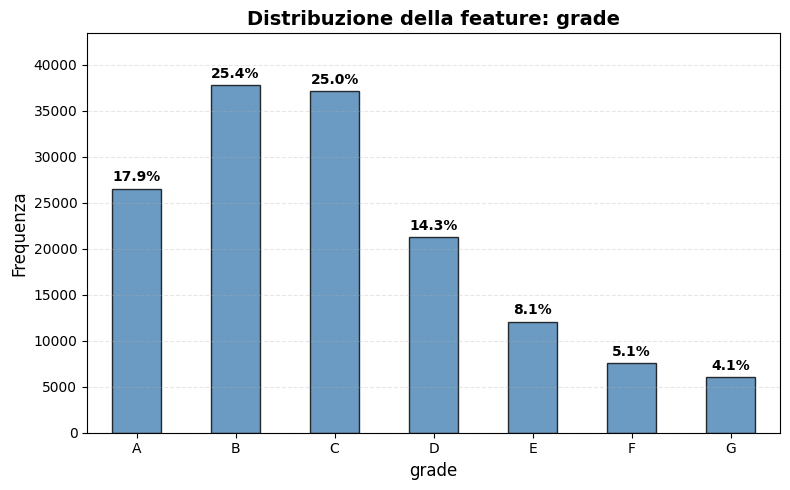

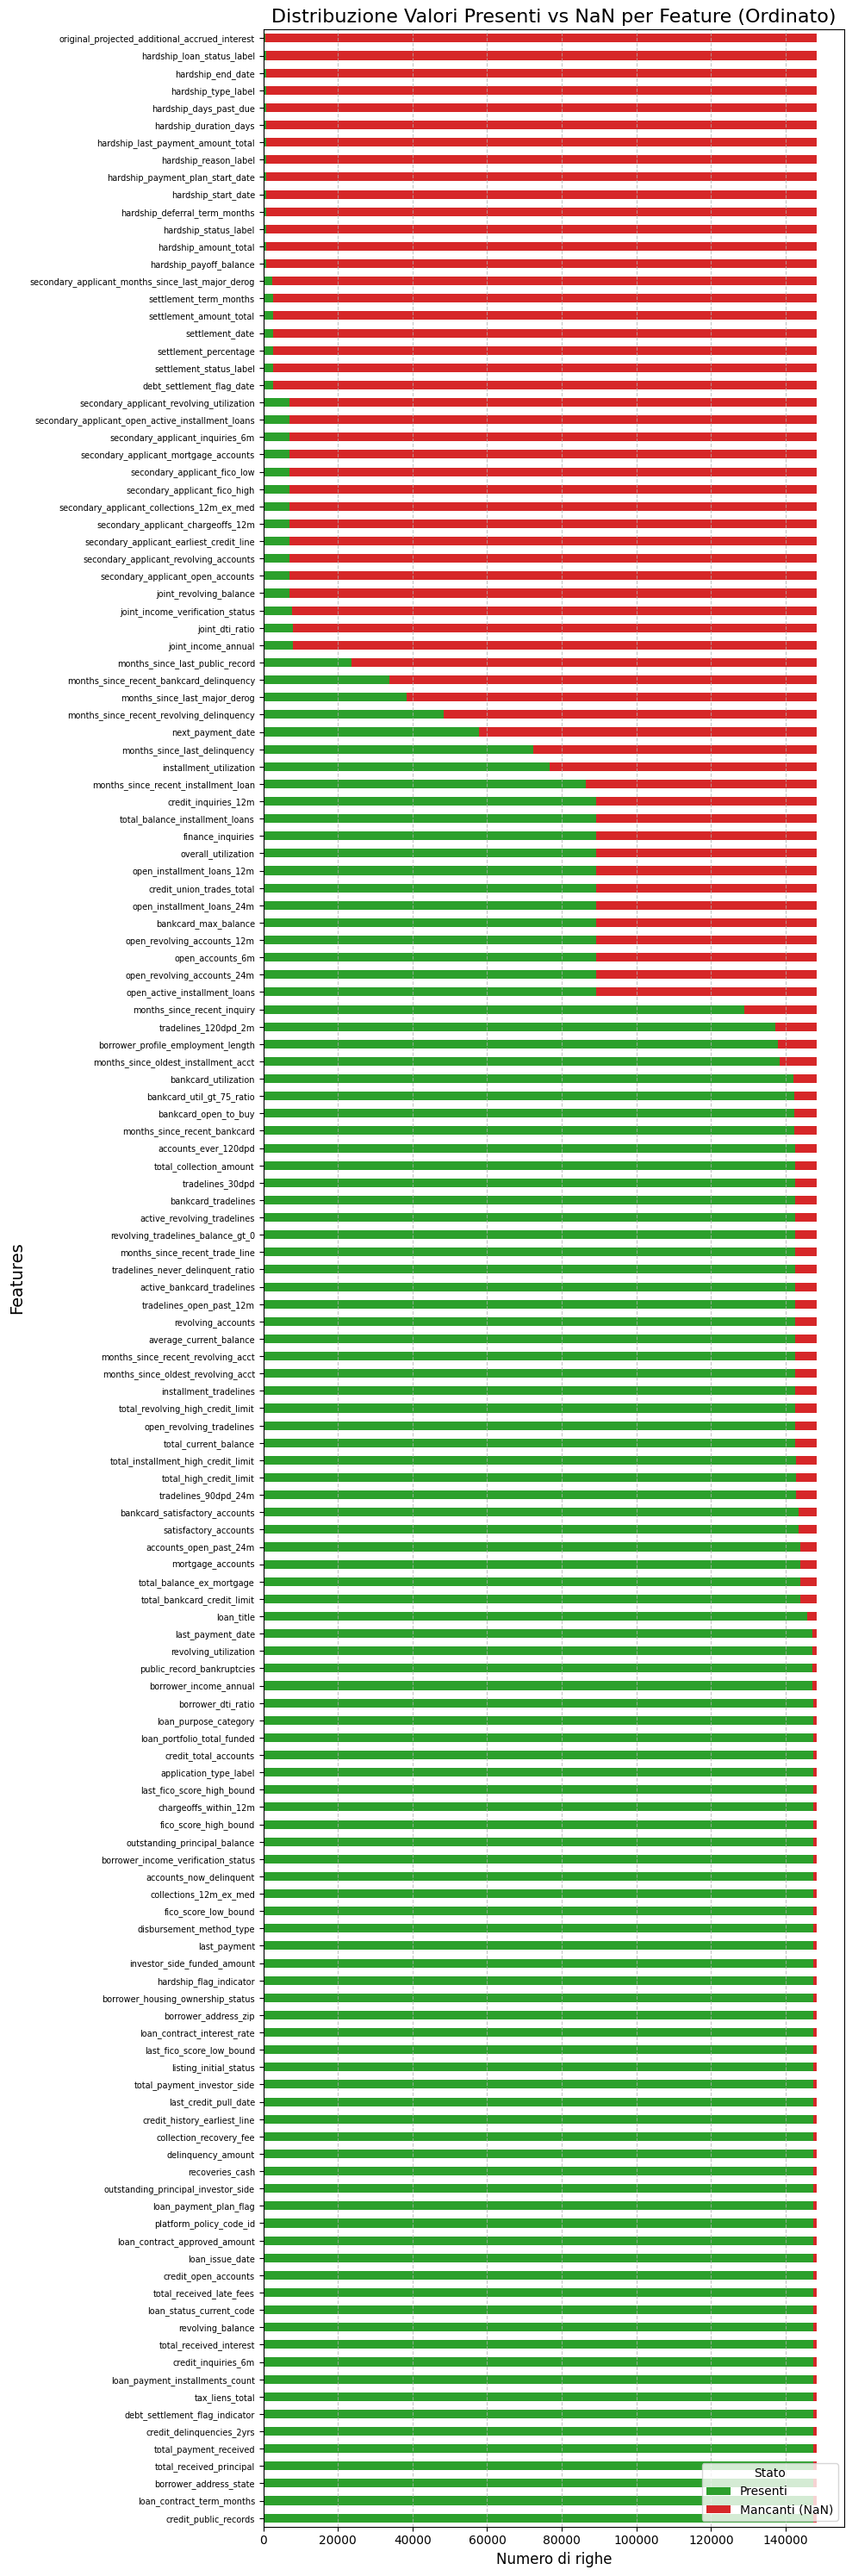

In [21]:
plot_feature_distribution(y, "grade")
plot_nan(X)

## 4. Features manipulation

In [22]:
for i in X.dtypes.unique():
    print("Type", i)

Type float64
Type str


In [23]:
# Teniamo una flag per indicare se un hardship loan e' stato concesso o meno
# X['has_hardship_plan'] = X['hardship_start_date'].notna().astype(float)

In [24]:
X = drop_high_nan_columns(X)

Colonne rimosse (> 95.0% NaN):
['joint_revolving_balance', 'secondary_applicant_fico_low', 'secondary_applicant_fico_high', 'secondary_applicant_earliest_credit_line', 'secondary_applicant_inquiries_6m', 'secondary_applicant_mortgage_accounts', 'secondary_applicant_open_accounts', 'secondary_applicant_revolving_utilization', 'secondary_applicant_open_active_installment_loans', 'secondary_applicant_revolving_accounts', 'secondary_applicant_chargeoffs_12m', 'secondary_applicant_collections_12m_ex_med', 'secondary_applicant_months_since_last_major_derog', 'hardship_type_label', 'hardship_reason_label', 'hardship_status_label', 'hardship_deferral_term_months', 'hardship_amount_total', 'hardship_start_date', 'hardship_end_date', 'hardship_payment_plan_start_date', 'hardship_duration_days', 'hardship_days_past_due', 'hardship_loan_status_label', 'original_projected_additional_accrued_interest', 'hardship_payoff_balance', 'hardship_last_payment_amount_total', 'debt_settlement_flag_date', 'set

### Categorical features

In [25]:
##### FEATURES EXTRACTION ######
# Trasforma "36 months" e "60 months" in float type
print("\n", X['loan_contract_term_months'].unique())
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)

# Strip della stringa "years"
# Trasforma anni in float: < 1 diventa 0, 10+ diventa 10
print("\n", X['loan_contract_term_months'].unique())
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace({ '< 1': 0}).astype(float)


##### DROP FEATURES #####
categorical_to_drop = [
  'loan_title',                         # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
  'borrower_address_zip',               # non significant column, esiste una colonna per identificazione stati
]

X = X.drop(columns=categorical_to_drop)


 <StringArray>
[' 36 months', ' 60 months', nan]
Length: 3, dtype: str

 [36. 60. nan]


### Numerical features

In [26]:
# 1. DROP: Data Leakage (Future Information)
numerical_to_drop = [
    # Future income for loaner
    'total_payment_received', 'total_received_principal', 'recoveries_cash',
    'collection_recovery_fee', 'last_payment', 'outstanding_principal_balance',
    'total_received_interest', 'total_received_late_fees',
]

X = X.drop(columns=numerical_to_drop)


print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 101



In [27]:
# 2. DROP: Secondary/Joint Applicant info
# application_type_label ci informa gia' se il tipo di prestito e' individual o

joint_and_secondary_cols = [col for col in X.columns if col.startswith('joint_') or col.startswith('secondary_')]

# DROP: tutti i campi relativi a settlement sono data leakage
settlement_cols = [col for col in X.columns if 'settlement' in col]

to_drop = joint_and_secondary_cols + settlement_cols

X = X.drop(columns=to_drop)

print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 97



In [28]:
# Feature categoriche in cui i valori NaN sono riempiti con una nuova label Unknown
categorical_to_unknown = [
  'borrower_address_state',
  'loan_purpose_category',
  'loan_status_current_code',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

# 2. Fill with 'unknown'
for col in categorical_to_unknown:
    X[col] = X[col].fillna('unknown')


# 3. KEEP & FILL: "Months Since" columns (NaN = Never happened)
# We fill with a large number (e.g., 100 months) to signify "very long time ago / never"
structural_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency'
]

for col in structural_cols:
    X[col] = X[col].fillna(100)


In [29]:
##### DATES #####
X['loan_issue_date'] = pd.to_datetime(X['loan_issue_date'], format='%b-%Y')

X['issue_month'] = X['loan_issue_date'].dt.month
X['issue_year'] = X['loan_issue_date'].dt.year

# cyclical Encoding
X['issue_month_sin'] = np.sin(2 * np.pi * X['issue_month'] / 12)
X['issue_month_cos'] = np.cos(2 * np.pi * X['issue_month'] / 12)

# calculate
X['credit_history_earliest_line'] = pd.to_datetime(X['credit_history_earliest_line'], format='%b-%Y')

# Numero mesi passati tra prima richiesta credito e loan date
X['months_since_earliest_cr_line'] = (
    (X['loan_issue_date'].dt.year - X['credit_history_earliest_line'].dt.year) * 12 +
    (X['loan_issue_date'].dt.month - X['credit_history_earliest_line'].dt.month)
)


# Tutte le features rimanenti con date non sono rilevanti (leakage)
date_cols = [col for col in X.columns if 'date' in col]
to_drop = [
    'credit_history_earliest_line',     # used for feature extraction
    'issue_month',                      # used for feature extraction: sin/cos encoding
    ] + date_cols


X = X.drop(columns=to_drop)
print(f"Columns remaining: {X.shape[1]}")

Columns remaining: 96


## NaN management

In [30]:
print_nan(X)

                                  Feature    Type   Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                             Unique Values
                loan_contract_term_months float64   890               0.60%              2                                                                                                                                                                                                      [np.float64(36.0), np.float64(60.0)]
                   loan_payment_plan_flag     str   949               0.64%              2                                                                                                                                                                                                                                ['n', 'y']
                   listin

In [31]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [32]:
# Feature categoriche in cui i valori NaN possono essere riempiti con la moda:
# valori con 2 etichette, in cui la mancanza di un dato viene trattato come "no" o come occorrenza piu' frequente
fill_to_mode =[
  # Categorical
  'disbursement_method_type',
  'application_type_label',
  'listing_initial_status',
  'loan_payment_plan_flag',
  'hardship_flag_indicator',      # n/y
  'loan_payment_plan_flag',       # n/y

  # Numerical
  'loan_contract_term_months'  # 36/60 mesi
]

for i in fill_to_mode:
    print(X[i].unique())


# 1. Setup the imputer with 'most_frequent' (Mode)
mode_imputer = SimpleImputer(strategy='most_frequent')

# 2. Fit on TRAIN only (Learn the most common categories)
# It's important to select only these columns to avoid errors with other types
mode_imputer.fit(X_train[fill_to_mode])

# 3. Transform BOTH (Fill NaNs)
# We assign the result back to the specific columns to keep the DataFrame structure
X_train[fill_to_mode] = mode_imputer.transform(X_train[fill_to_mode])
X_val[fill_to_mode] = mode_imputer.transform(X_val[fill_to_mode])





<StringArray>
['cash', 'directpay', nan]
Length: 3, dtype: str
<StringArray>
['individual', 'joint app', nan]
Length: 3, dtype: str
<StringArray>
['f', 'w', nan]
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
[36. 60. nan]


In [33]:

""" numerical_to_mean = [
    'borrower_dti_ratio',
    'borrower_income_annual',
    'revolving_utilization',
    'total_revolving_high_credit_limit',
] """

numerical_to_mean = X_train.select_dtypes(include=['float', 'int']).columns

# Setup the imputer
imputer = SimpleImputer(strategy='mean')

# Fit on TRAIN only (Learn the medians)
imputer.fit(X_train[numerical_to_mean])

# Transform BOTH (Fill NaNs)
X_train[numerical_to_mean] = imputer.transform(X_train[numerical_to_mean])
X_val[numerical_to_mean] = imputer.transform(X_val[numerical_to_mean])

In [34]:
print(X_train['hardship_flag_indicator'].unique())

<StringArray>
['n', 'y']
Length: 2, dtype: str


                                  Feature    Type  Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                             Unique Values
                loan_contract_term_months  object    0               0.00%              2                                                                                                                                                                                                                              [36.0, 60.0]
                   loan_payment_plan_flag     str    0               0.00%              2                                                                                                                                                                                                                                ['n', 'y']
                   listing_i

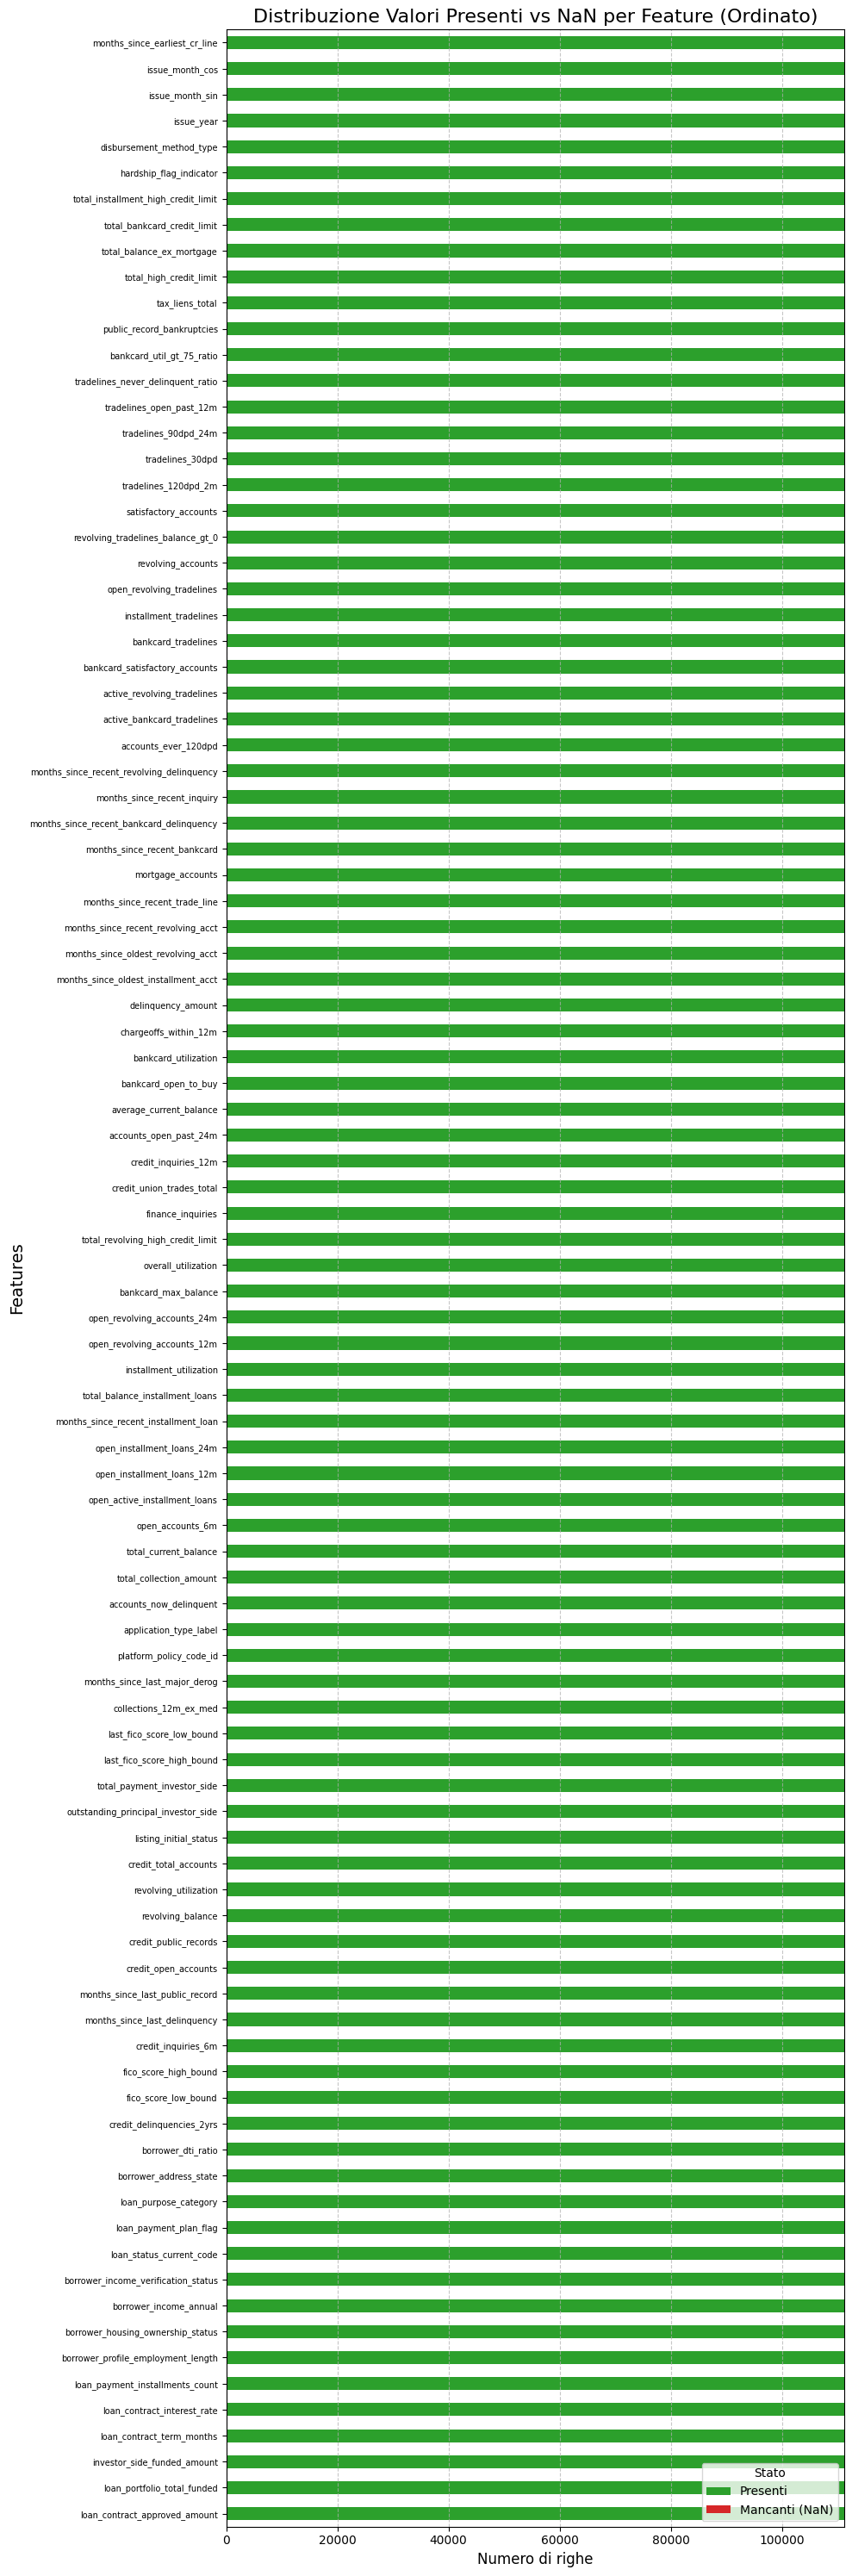

                                  Feature    Type  Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                  Unique Values
                loan_contract_term_months  object    0               0.00%              2                                                                                                                                                                                                                   [36.0, 60.0]
                   loan_payment_plan_flag     str    0               0.00%              2                                                                                                                                                                                                                     ['n', 'y']
                   listing_initial_status     str    0       

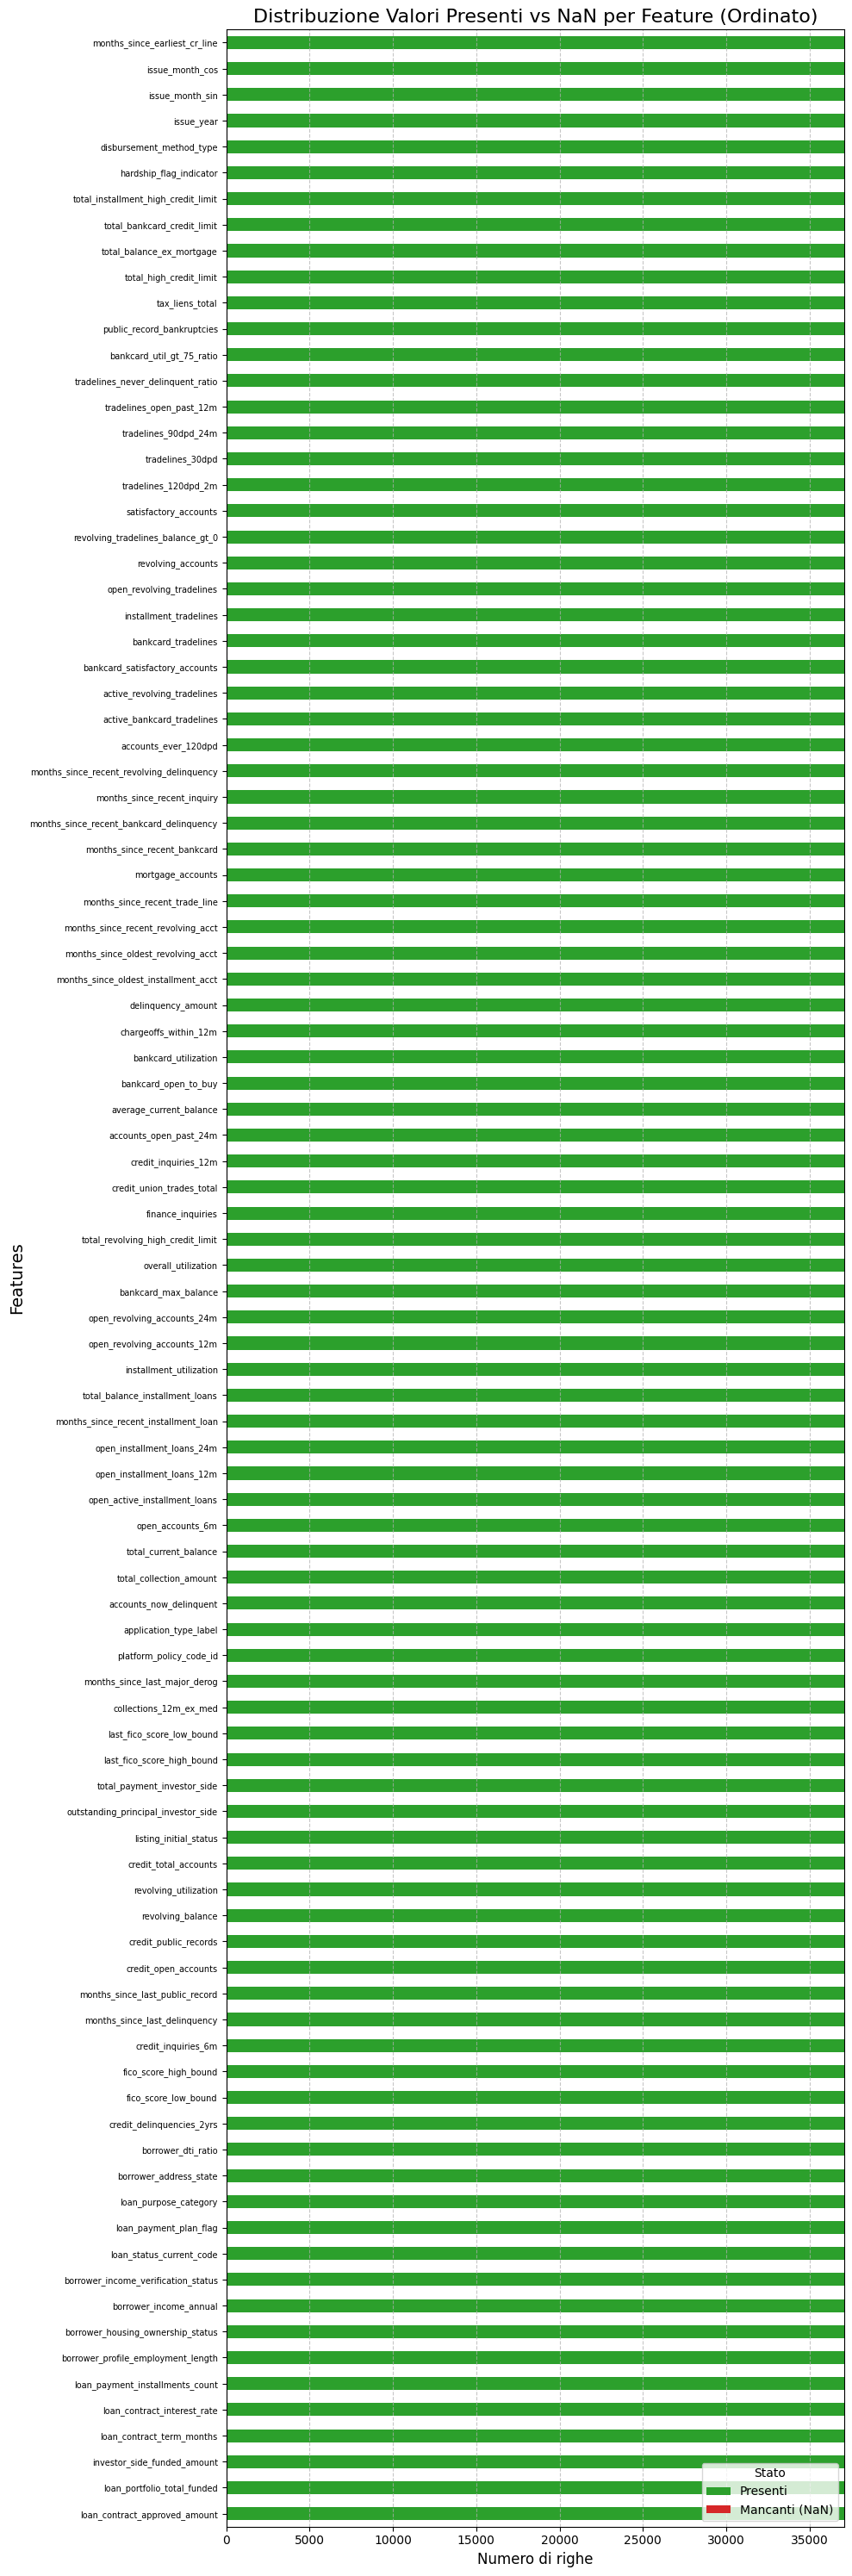

In [35]:
print_nan(X_train)
plot_nan(X_train)

print_nan(X_val)
plot_nan(X_val)

## Features encoding

In [36]:

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create encoder with handle_unknown to deal with unseen categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(X_train[categorical_features])

# Transform both sets
X_train_encoded = ohe.transform(X_train[categorical_features])
X_val_encoded = ohe.transform(X_val[categorical_features])

# Get feature names for the encoded columns
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Create DataFrames with the encoded features
X_train_ohe = pd.DataFrame(X_train_encoded,
                           columns=encoded_feature_names,
                           index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_encoded,
                         columns=encoded_feature_names,
                         index=X_val.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_features).join(X_train_ohe)
X_val = X_val.drop(columns=categorical_features).join(X_val_ohe)


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)


print(X_train.shape[1])
print(X_train.head())

/tmp/ipykernel_12675/3585451326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


184
        loan_contract_approved_amount  loan_portfolio_total_funded  \
27319                          8000.0                  8636.284704   
92768                         10000.0                 10000.000000   
47317                         14700.0                 14700.000000   
114343                        14000.0                 12535.938009   
64675                         25000.0                 25000.000000   

        investor_side_funded_amount loan_contract_term_months  \
27319                    8000.00000                      36.0   
92768                   10588.35588                      60.0   
47317                   14700.00000                      36.0   
114343                  14000.00000                      60.0   
64675                   25000.00000                      36.0   

        loan_contract_interest_rate  loan_payment_installments_count  \
27319                         14.46                           275.22   
92768                         22.99     

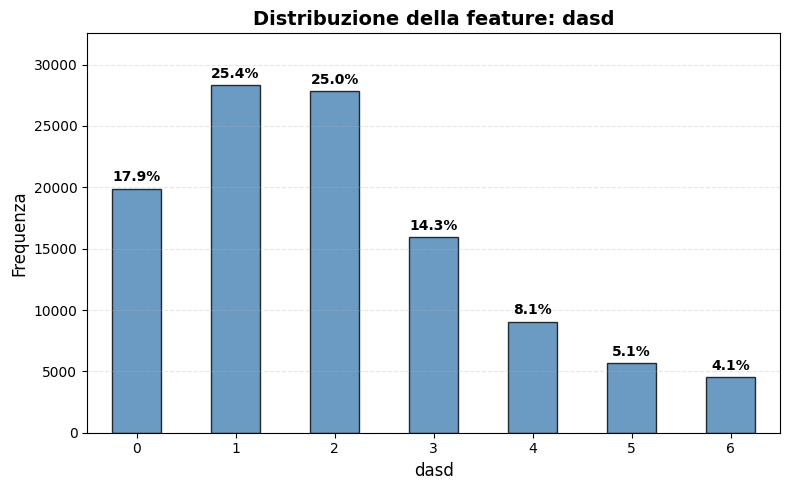

In [37]:
plot_feature_distribution(y_train, "dasd")

In [38]:
### OUTLIERS SCATTERPLOTS


""" numerical_cols = X.select_dtypes(include=['float', 'int']).columns
#categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 2. Loop and Plot
for col in numerical_cols:
    plt.figure(figsize=(10, 4))

    if col in numerical_cols:
        # --- NUMERICAL: SCATTER PLOT ---
        # Plot Index vs Value. Outliers will appear vertically distant from the main cloud.
        plt.scatter(x=X.index, y=X[col], alpha=0.5)

        # Optional: Add lines for Mean +/- 3 Std Dev to help identify extreme values
        mean = X[col].mean()
        std = X[col].std()
        plt.axhline(mean + 3*std, color='r', linestyle='--', label='Mean + 3SD')
        plt.axhline(mean - 3*std, color='r', linestyle='--', label='Mean - 3SD')
        plt.legend()
        plt.title(f"Numerical Outliers: {col}")
        plt.ylabel("Value")
        plt.xlabel("Index (Row Number)")

    else:
        # --- CATEGORICAL: BAR CHART ---
        # Outliers here are 'Rare Categories'. We plot frequency.
        # If a bar is extremely short (e.g., count=1), it's a rare category.
        X_train[col].value_counts().plot(kind='bar', color='orange')
        plt.title(f"Categorical Frequencies: {col}")
        plt.ylabel("Count")
        plt.xlabel("Category")

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    #plt.show()
 """

' numerical_cols = X.select_dtypes(include=[\'float\', \'int\']).columns\n#categorical_cols = X.select_dtypes(include=[\'object\', \'category\']).columns\n\n# 2. Loop and Plot\nfor col in numerical_cols:\n    plt.figure(figsize=(10, 4))\n\n    if col in numerical_cols:\n        # --- NUMERICAL: SCATTER PLOT ---\n        # Plot Index vs Value. Outliers will appear vertically distant from the main cloud.\n        plt.scatter(x=X.index, y=X[col], alpha=0.5)\n\n        # Optional: Add lines for Mean +/- 3 Std Dev to help identify extreme values\n        mean = X[col].mean()\n        std = X[col].std()\n        plt.axhline(mean + 3*std, color=\'r\', linestyle=\'--\', label=\'Mean + 3SD\')\n        plt.axhline(mean - 3*std, color=\'r\', linestyle=\'--\', label=\'Mean - 3SD\')\n        plt.legend()\n        plt.title(f"Numerical Outliers: {col}")\n        plt.ylabel("Value")\n        plt.xlabel("Index (Row Number)")\n\n    else:\n        # --- CATEGORICAL: BAR CHART ---\n        # Outliers he

In [39]:
# Run and display
outlier_stats = calculate_outlier_percentage(X)
with pd.option_context('display.max_rows', None):
    print(outlier_stats)

# analyze_and_plot_outliers(X)

                                       Column  Lower Cutoff  Upper Cutoff  \
57   months_since_recent_bankcard_delinquency        100.00        100.00   
60                       accounts_ever_120dpd          0.00          0.00   
9                   credit_delinquencies_2yrs          0.00          0.00   
16                      credit_public_records          0.00          0.00   
14            months_since_last_public_record        100.00        100.00   
28                    total_collection_amount          0.00          0.00   
25              months_since_last_major_derog         47.50        131.50   
76                 public_record_bankruptcies          0.00          0.00   
20        outstanding_principal_investor_side      -8880.49      14800.82   
56               months_since_recent_bankcard        -28.50         63.50   
47                       bankcard_open_to_buy     -16235.59      31213.98   
26                    platform_policy_code_id          1.00          1.00   

### PCA

In [40]:
"""
# 1. Selezione delle sole colonne numeriche
# (Assicurati di aver già rimosso o trasformato le date e le categoriche)
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_val_numeric = X_val.select_dtypes(include=[np.number])

# 2. Imputazione dei valori mancanti (la PCA non ammette NaN)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_numeric)
X_val_imputed = imputer.transform(X_val_numeric)

# 3. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

# 4. Applicazione PCA
# Usiamo n_components=0.95 per mantenere il 95% della varianza totale
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Dimensioni originali: {X_train_scaled.shape[1]}")
print(f"Dimensioni dopo PCA (90% varianza): {X_train_pca.shape[1]}")

# --- Visualizzazione della Varianza Spiegata ---
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.title('Analisi della Varianza per PCA')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid()
plt.show() """

'\n# 1. Selezione delle sole colonne numeriche\n# (Assicurati di aver già rimosso o trasformato le date e le categoriche)\nX_train_numeric = X_train.select_dtypes(include=[np.number])\nX_val_numeric = X_val.select_dtypes(include=[np.number])\n\n# 2. Imputazione dei valori mancanti (la PCA non ammette NaN)\nimputer = SimpleImputer(strategy=\'median\')\nX_train_imputed = imputer.fit_transform(X_train_numeric)\nX_val_imputed = imputer.transform(X_val_numeric)\n\n# 3. Standardizzazione (Fondamentale per la PCA)\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train_imputed)\nX_val_scaled = scaler.transform(X_val_imputed)\n\n# 4. Applicazione PCA\n# Usiamo n_components=0.95 per mantenere il 95% della varianza totale\npca = PCA(n_components=0.90)\nX_train_pca = pca.fit_transform(X_train_scaled)\nX_val_pca = pca.transform(X_val_scaled)\n\nprint(f"Dimensioni originali: {X_train_scaled.shape[1]}")\nprint(f"Dimensioni dopo PCA (90% varianza): {X_train_pca.shape[1]}")\n\n# --- 

In [41]:
"""

# 1. Trasforma X_train_pca in DataFrame
# Usiamo l'indice di X_train_ohe per garantire l'allineamento perfetto delle righe
X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f'PCA_{i+1}' for i in range(X_train_pca.shape[1])],
    index=X_train_ohe.index
)

# 2. Unione (Concatenazione orizzontale) per il Training Set
X_train_final = pd.concat([X_train_ohe, X_train_pca_df], axis=1)

# 3. Trasforma X_val_pca in DataFrame
X_val_pca_df = pd.DataFrame(
    X_val_pca,
    columns=[f'PCA_{i+1}' for i in range(X_val_pca.shape[1])],
    index=X_val_ohe.index
)

# 4. Unione per il Validation Set
X_val_final = pd.concat([X_val_ohe, X_val_pca_df], axis=1)

print(f"Nuova dimensione Training Set: {X_train_final.shape}")
print(f"Nuova dimensione Validation Set: {X_val_final.shape}") """

'\n\n# 1. Trasforma X_train_pca in DataFrame\n# Usiamo l\'indice di X_train_ohe per garantire l\'allineamento perfetto delle righe\nX_train_pca_df = pd.DataFrame(\n    X_train_pca,\n    columns=[f\'PCA_{i+1}\' for i in range(X_train_pca.shape[1])],\n    index=X_train_ohe.index\n)\n\n# 2. Unione (Concatenazione orizzontale) per il Training Set\nX_train_final = pd.concat([X_train_ohe, X_train_pca_df], axis=1)\n\n# 3. Trasforma X_val_pca in DataFrame\nX_val_pca_df = pd.DataFrame(\n    X_val_pca,\n    columns=[f\'PCA_{i+1}\' for i in range(X_val_pca.shape[1])],\n    index=X_val_ohe.index\n)\n\n# 4. Unione per il Validation Set\nX_val_final = pd.concat([X_val_ohe, X_val_pca_df], axis=1)\n\nprint(f"Nuova dimensione Training Set: {X_train_final.shape}")\nprint(f"Nuova dimensione Validation Set: {X_val_final.shape}") '

In [42]:
""" # 1. Recupera i nomi delle colonne originali usate per la PCA
# (Assumendo che X_train_scaled sia il risultato dello StandardScaler)
feature_names = X_train.select_dtypes(include=[np.number]).columns

# 2. Crea un DataFrame con l'importanza relativa (Varianza Spiegata)
pca_importance = pd.DataFrame({
    'Componente': [f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Spiegata': pca.explained_variance_ratio_,
    'Varianza Cumulativa': np.cumsum(pca.explained_variance_ratio_)
})

print("--- Importanza Relativa dei Componenti PCA ---")
print(pca_importance.to_string(index=False))

# 3. Analisi dei "Loadings" (quali feature pesano di più sui componenti)
# Prendiamo ad esempio il primo componente (PCA_1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    index=feature_names
)

print("\n--- Top 5 Feature originali per importanza in PCA_1 ---")
# Usiamo il valore assoluto perché un peso molto negativo è importante quanto uno positivo
top_features_pca1 = loadings['PCA_2'].abs().sort_values(ascending=False)
print(top_features_pca1) """

' # 1. Recupera i nomi delle colonne originali usate per la PCA\n# (Assumendo che X_train_scaled sia il risultato dello StandardScaler)\nfeature_names = X_train.select_dtypes(include=[np.number]).columns\n\n# 2. Crea un DataFrame con l\'importanza relativa (Varianza Spiegata)\npca_importance = pd.DataFrame({\n    \'Componente\': [f\'PCA_{i+1}\' for i in range(len(pca.explained_variance_ratio_))],\n    \'Varianza Spiegata\': pca.explained_variance_ratio_,\n    \'Varianza Cumulativa\': np.cumsum(pca.explained_variance_ratio_)\n})\n\nprint("--- Importanza Relativa dei Componenti PCA ---")\nprint(pca_importance.to_string(index=False))\n\n# 3. Analisi dei "Loadings" (quali feature pesano di più sui componenti)\n# Prendiamo ad esempio il primo componente (PCA_1)\nloadings = pd.DataFrame(\n    pca.components_.T,\n    columns=[f\'PCA_{i+1}\' for i in range(len(pca.explained_variance_ratio_))],\n    index=feature_names\n)\n\nprint("\n--- Top 5 Feature originali per importanza in PCA_1 ---")\n# 

# Training

## Define the scalers to be used

In [43]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

## Apply Random Forests with hyperparameters tuning

In [ ]:
''' param_grid_rf = {
    'clf__n_estimators': [100],
    'clf__max_depth': [5],
    #'clf__max_features': [None, 'sqrt', 'log2'],
    #'clf__criterion': ['gini', 'entropy', 'log_loss'],
    #'clf__max_depth': [None, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}
 '''

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__max_depth': [None, 10, 20]
}

pipeline = Pipeline([
    ("clf", RandomForestClassifier(random_state=seed, n_jobs=-1, class_weight='balanced'))        #No oversampling needed in random forest (?)
])

grid = GridSearchCV(pipeline, param_grid_rf, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
grid.fit(X_train, y_train)

print("Performance:", grid.best_estimator_)
print("Performance:", grid.best_params_)

with open("rf.save","wb") as file:
    pickle.dump(grid.best_estimator_['clf'], file)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/loc

KeyboardInterrupt: 

/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



 EVALUATION: Random Forest (Best)

>>> PARAMETRI RILEVANTI:
  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'oob_score': False, 'random_state': 42, 'warm_start': False}

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      6634
           1       0.72      0.76      0.74      9435
           2       0.68      0.71      0.69      9270
           3       0.66      0.49      0.56      5314
           4       0.46      0.32      0.38      3021
           5       0.65      0.50      0.57      1881
           6       0.59      0.74      0.66      1521

    accuracy                           0.69     37076
   macro avg       0.65      0.64    

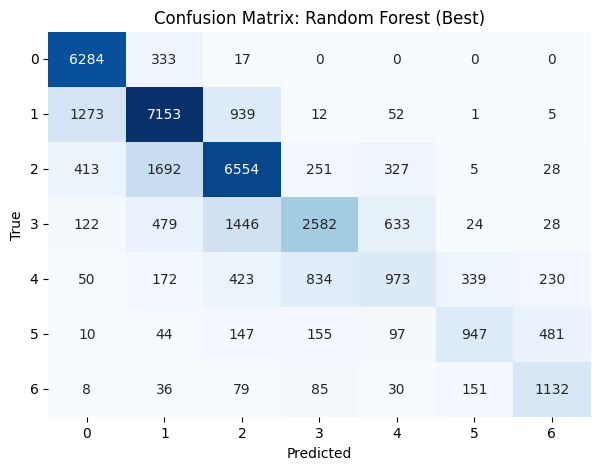

In [50]:
evaluate_model("rf.save", X_val, y_val, "Random Forest (Best)")

In [ ]:
visualize_rf_tree("rf.save", X_train, y_train, max_depth=5)

In [ ]:
def plot_feature_importance(model_input, feature_names, top_n=20, title="Top Feature Importance"):
    """
    Estrae e visualizza le feature più importanti di una Random Forest.
    """
    model = None

    # 1. Caricamento (da file o oggetto)
    if isinstance(model_input, str):
        with open(model_input, "rb") as f:
            model = pickle.load(f)
    else:
        model = model_input

    # 2. Gestione Pipeline (estraiamo il classificatore 'clf')
    if hasattr(model, 'named_steps'):
        clf = model.named_steps.get('clf', model.steps[-1][1])
    else:
        clf = model

    # 3. Estrazione importanze
    if not hasattr(clf, 'feature_importances_'):
        print("Errore: Il modello non supporta feature_importances_ (non è un modello basato su alberi).")
        return

    importances = clf.feature_importances_

    # Creiamo un DataFrame per facilitare l'ordinamento
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # 4. Plotting
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(top_n), palette='viridis')

    plt.title(f"{title} (Top {top_n})", fontsize=15)
    plt.xlabel("Importanza (Gini Impurity Decrease)")
    plt.ylabel("Variabili")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return fi_df

# --- ESEMPIO DI UTILIZZO ---
feature_list = X_train.columns.tolist()
importance_table = plot_feature_importance("rf.save", feature_list, top_n=15)

In [ ]:
plot_top_correlations_split(X_train, y_train)

## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
# SVC param grid
# L' uso di LinearSVC su classic SVC (inserire differenza) e' necessario causa n_sample esteso (si consiglia se > 10k-ish)
''' param_grid_svc = {
    'clf__C': [10],      #[0.1, 1, 10, 100, 1000],
    'clf__kernel': ["linear", "poly"]     #, "rbf"
    } '''

param_grid_lsvc = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__max_iter': [1000, 2000]
}

# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            # 1. Scale first (LinearSVC needs it)
            ('scaler', scaler),

            # 2. SMOTE inside the fold (Prevents leakage!)
            #('smote', SMOTE(random_state=seed)),

            #("clf", SVC(random_state=seed))

            # 3. Use Fast LinearSVC
            ('clf', LinearSVC(dual=False, loss='squared_hinge', class_weight='balanced', random_state=seed))             #Prefer dual=False when n_samples > n_features
        ])

        # Perform Grid Search
        grid =  GridSearchCV(pipeline, param_grid_lsvc, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
        grid.fit(X_train, y_train)


        print("Performance:", grid.best_estimator_)
        print("Performance:", grid.best_params_)


        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            with open("svc_scaler.save","wb") as file:
                pickle.dump(grid.best_estimator_['scaler'], file)
            with open("svc.save","wb") as file:
                pickle.dump(grid.best_estimator_['clf'], file)


/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearSVC was fitted without feature names
  warnings.warn(



 EVALUATION: SVC

>>> PARAMETRI RILEVANTI:
  {'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001}

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.24      0.36      0.29      6634
           1       0.16      0.00      0.01      9435
           2       0.30      0.07      0.11      9270
           3       0.16      0.27      0.20      5314
           4       0.08      0.39      0.13      3021
           5       0.11      0.01      0.02      1881
           6       0.02      0.00      0.01      1521

    accuracy                           0.15     37076
   macro avg       0.15      0.16      0.11     37076
weighted avg       0.19      0.15      0.12     37076

Accuracy: 0.1534
Balanced Accuracy: 0.1583


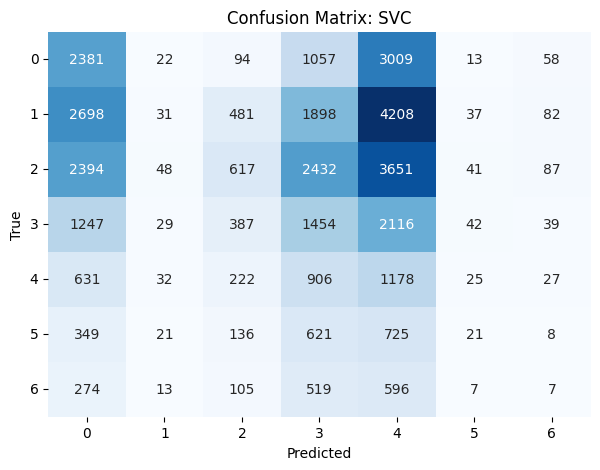

In [48]:
evaluate_model("svc.save", X_val, y_val, "SVC")

## Apply K Neighbors Classifier with hyperparameters tuning

In [56]:
# KNN param grid
param_grid_knn = {
    'clf__n_neighbors': [5, 15, 30],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}
# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = ImbPipeline([
            ('scaler', scaler),
            ('smote', SMOTE(random_state=seed)),
            ('clf', KNeighborsClassifier(n_jobs=-1))
        ])

        # Perform Grid Search
        grid =  GridSearchCV(pipeline, param_grid_knn, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
        grid.fit(X_train, y_train)


        print("Performance:", grid.best_estimator_)
        print("Performance:", grid.best_params_)


        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            with open("knn_scaler.save","wb") as file:
                pickle.dump(grid.best_estimator_['scaler'], file)
            with open("knn.save","wb") as file:
                pickle.dump(grid.best_estimator_['clf'], file)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 2/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform;, score=0.293 total time= 1.7min
[CV 1/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform;, score=0.295 total time= 1.7min
[CV 3/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform;, score=0.296 total time= 1.7min
[CV 4/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform;, score=0.300 total time= 1.7min
[CV 5/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=uniform;, score=0.288 total time= 1.7min
[CV 2/5] END clf__metric=euclidean, clf__n_neighbors=15, clf__weights=uniform;, score=0.305 total time= 1.6min
[CV 4/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=distance;, score=0.299 total time= 1.6min
[CV 2/5] END clf__metric=euclidean, clf__n_neighbors=5, clf__weights=distance;, score=0.291 total time= 1.7min
[CV 1/5] END clf__metric=euclidean, clf__n_neighbors=5, 

/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



 EVALUATION: KNN

>>> PARAMETRI RILEVANTI:
  - K (Neighbors): 30
  (Altri params: ['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.19      0.80      0.31      6634
           1       0.24      0.25      0.24      9435
           2       0.00      0.00      0.00      9270
           3       0.00      0.00      0.00      5314
           4       0.00      0.00      0.00      3021
           5       0.00      0.00      0.00      1881
           6       0.00      0.00      0.00      1521

    accuracy                           0.21     37076
   macro avg       0.06      0.15      0.08     37076
weighted avg       0.10      0.21      0.12     37076

Accuracy: 0.2057
Balanced Accuracy: 0.1494


/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/App/miniforge3/envs/loan-risk-rating/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

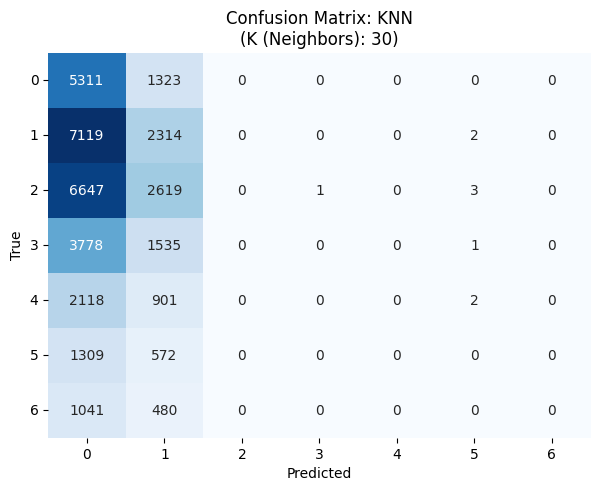

In [53]:
evaluate_model("knn.save", X_val, y_val, "KNN")